In [1]:
from pathlib import Path


# Set this to the result folder for the dataset to plot.
RESULTS_FOLDER = Path("benchmark/results/scm20d")


In [ ]:
import json
import math

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


if RESULTS_FOLDER.is_absolute():
    results_root = RESULTS_FOLDER.expanduser().resolve()
else:
    working_directory = Path.cwd().resolve()
    results_root = next(
        (repository_root / RESULTS_FOLDER).resolve()
        for repository_root in (working_directory, *working_directory.parents)
        if (repository_root / RESULTS_FOLDER).is_dir()
    )

dataset_name = results_root.name.upper()
records = []
for metrics_path in sorted(results_root.rglob("metrics.json")):
    relative_path = metrics_path.relative_to(results_root)
    if len(relative_path.parts) < 3:
        continue

    model_name = relative_path.parts[0]
    seed_name = metrics_path.parent.name
    with metrics_path.open(encoding="utf-8") as metrics_file:
        metrics = json.load(metrics_file)

    for metric_name, summary in metrics.items():
        if not isinstance(summary, dict):
            continue
        mean_value = summary.get("mean")
        if (
            isinstance(mean_value, (int, float))
            and not isinstance(mean_value, bool)
            and math.isfinite(mean_value)
        ):
            records.append(
                {
                    "model": model_name,
                    "seed": seed_name,
                    "metric": metric_name,
                    "mean": mean_value,
                }
            )

metrics_frame = pd.DataFrame.from_records(records)
metric_order = sorted(metrics_frame["metric"].unique())
model_order = sorted(metrics_frame["model"].unique())

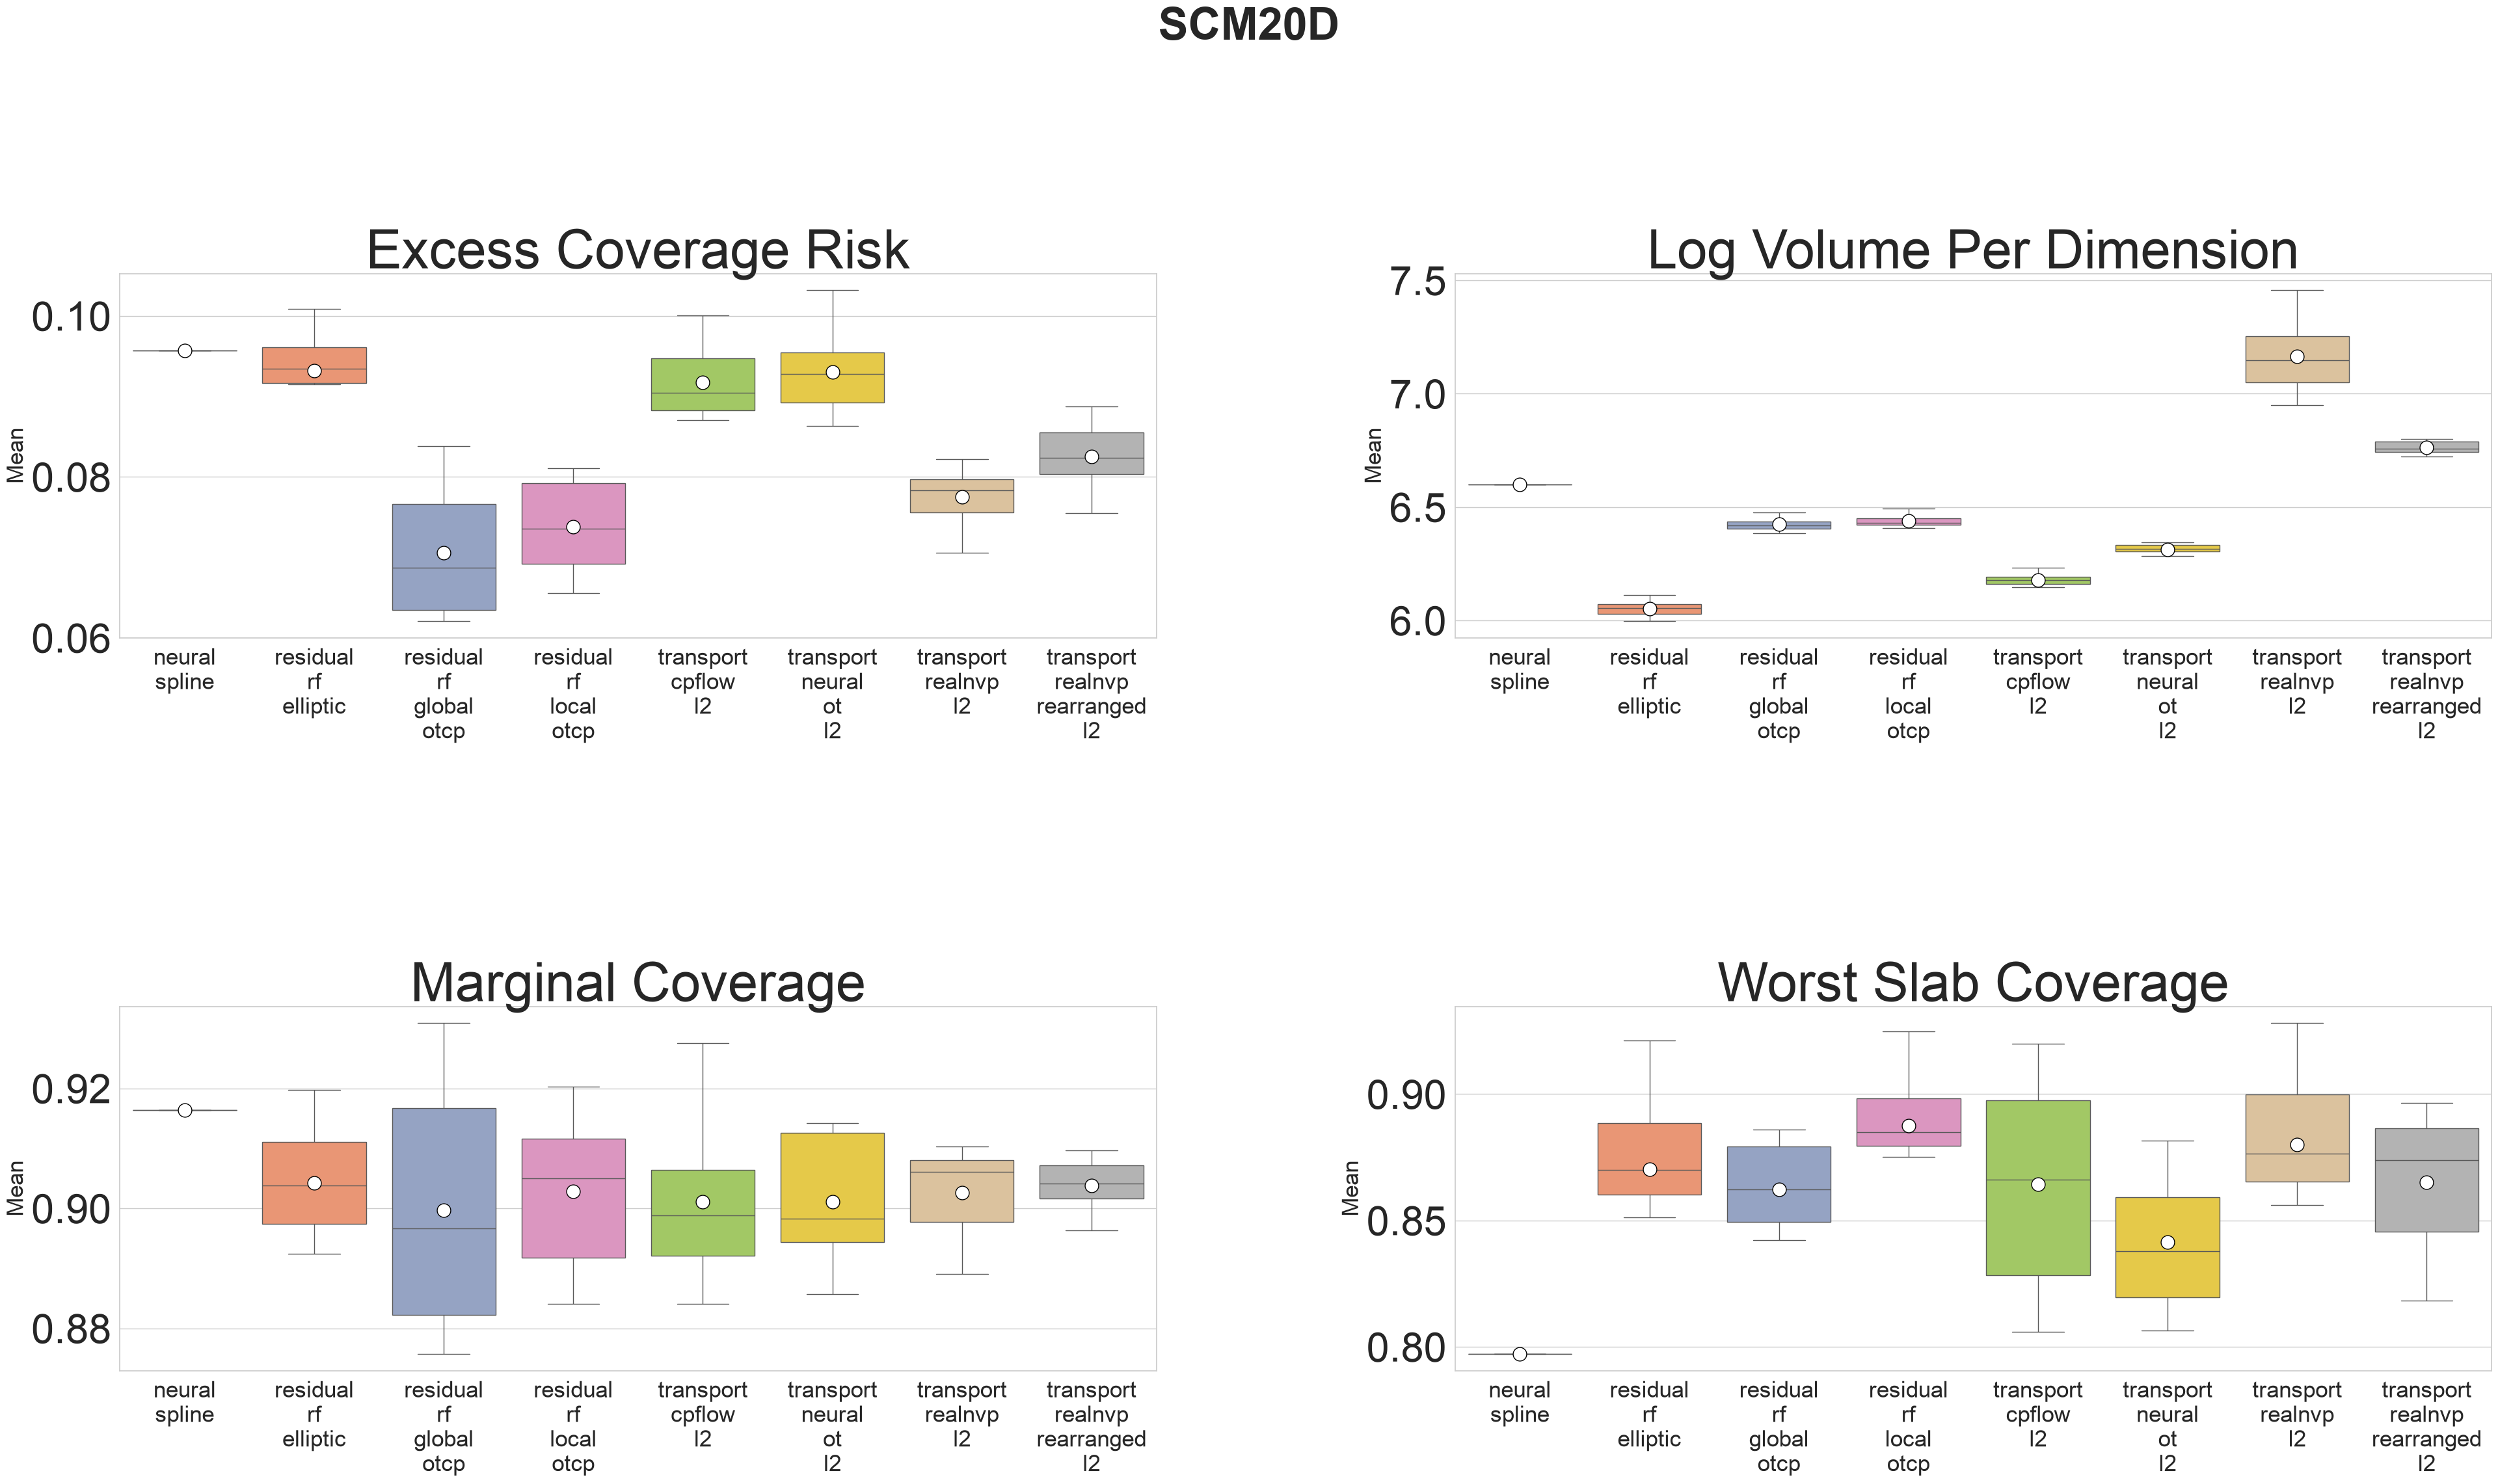

In [ ]:
TEXT_SCALE = 5.0
sns.set_theme(style="whitegrid", context="notebook", font_scale=TEXT_SCALE)

number_of_columns = 2
number_of_rows = math.ceil(len(metric_order) / number_of_columns)
figure, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(max(40, 5 * len(model_order)), 12 * number_of_rows),
    squeeze=False,
)
axes = axes.ravel()
palette = dict(
    zip(model_order, sns.color_palette("Set2", n_colors=len(model_order)))
)

for axis, metric_name in zip(axes, metric_order):
    metric_frame = metrics_frame.loc[metrics_frame["metric"] == metric_name]
    sns.boxplot(
        data=metric_frame,
        x="model",
        y="mean",
        hue="model",
        order=model_order,
        hue_order=model_order,
        palette=palette,
        legend=False,
        showfliers=False,
        showmeans=True,
        meanprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 15,
        },
        ax=axis,
    )
    axis.set_title(metric_name.replace("_", " ").title(), fontsize=60)
    axis.set_xlabel("")
    axis.set_ylabel("Mean", fontsize=25)
    axis.set_xticks(
        axis.get_xticks(),
        labels=[
            model_name.replace("_", "\n") for model_name in model_order
        ],
        rotation=0,
        horizontalalignment="center",
        fontsize=25,
    )
    axis.tick_params(axis="y", labelsize=45)

for axis in axes[len(metric_order):]:
    figure.delaxes(axis)

figure.suptitle(dataset_name, fontsize=50, fontweight="bold")
figure.tight_layout(rect=(0, 0, 1, 0.94), h_pad=4, w_pad=3)
plt.show()